# Bayesian Ink Concentration Classifier — Exploratory Development

**Goal**: Replace the existing kNN / logistic regression / weighted-score classifiers with Bayesian methods that:
1. Handle dense clusters in high-dimensional feature space
2. Provide calibrated uncertainty estimates
3. Discriminate petroleum concentrations (5 wt% vs 25 wt%) — the hardest task
4. Eventually support continuous concentration estimation

**Data**: Chroma paper samples only (no 52gm³ substrates)

---

In [1]:
# ── Core imports ──────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ── Scikit-learn imports (all gathered here to avoid NameErrors) ──────
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, cross_val_predict, LeaveOneOut,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.gaussian_process import GaussianProcessClassifier, GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    RBF, Matern, RationalQuadratic, ConstantKernel, WhiteKernel,
)
from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

# ── Plot settings ─────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.1)
%matplotlib inline

# ── Feature set used throughout the notebook ──────────────────────────
FEATURES = [
    "mean_I", "std_I", "skewness_I", "kurtosis_I",
    "entropy_I", "iqr_I", "pct_zero", "tail_delta_95_99",
]

# Subset used for classification (excluding mean_I which is Beer-Lambert confounded)
CONC_FEATURES = ["std_I", "skewness_I", "kurtosis_I", "entropy_I", "pct_zero", "tail_delta_95_99"]

# ── Data loading — chroma paper only ─────────────────────────────────
DATA_DIR = Path(
    "/Users/mattmccoy/GaTech Dropbox/Matthew McCoy/"
    "mattmccoy-research/research/binderjet/code/rfam_tool/session_data"
)

chroma_files = [
    DATA_DIR / "results_20250806_165713_5wtC_petro_largeset_chroma.csv",   # ink_key=1, 5 wt% petro
    DATA_DIR / "results_20250806_164335_25wtC_petro_largeset_chroma.csv",  # ink_key=2, 25 wt% petro
    DATA_DIR / "results_20250806_170841_25wtC_IPA_largeset_chroma.csv",    # ink_key=3, 25 wt% IPA
]

frames = []
for f in chroma_files:
    df = pd.read_csv(f)
    df["__source"] = f.name
    frames.append(df)

data = pd.concat(frames, ignore_index=True)

# Map ink_key to descriptive labels and concentration
INK_DESC = {1: "5 wt% petro", 2: "25 wt% petro", 3: "25 wt% IPA"}
CONC_MAP = {1: 5.0, 2: 25.0, 3: 25.0}  # wt% carbon
MATERIAL_MAP = {1: "Petroleum", 2: "Petroleum", 3: "IPA"}

data["ink_desc"] = data["ink_key"].map(INK_DESC)
data["conc_wt"] = data["ink_key"].map(CONC_MAP)
data["material"] = data["ink_key"].map(MATERIAL_MAP)

# ── Petroleum-only subset (the hard problem) ─────────────────────────
petro = data[data["ink_key"].isin([1, 2])].copy()
petro["conc_label"] = petro["ink_key"].map({1: "5 wt%", 2: "25 wt%"})

# ── Prepared arrays for classification ────────────────────────────────
# Binary concentration task: 5 wt% (1) vs 25 wt% (0)
X_conc = petro[CONC_FEATURES].fillna(0).values
y_conc = (petro["ink_key"] == 1).astype(int).values  # 1 = 5 wt%, 0 = 25 wt%

# Full 3-class material task
X_all = data[CONC_FEATURES].fillna(0).values
y_all = data["ink_key"].values

# Cross-validation strategy (reused everywhere)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── Summary ───────────────────────────────────────────────────────────
print(f"Total samples: {len(data)}")
print(f"Petroleum samples: {len(petro)} ({petro['conc_label'].value_counts().to_dict()})")
print(f"\nClass distribution:")
print(data["ink_desc"].value_counts().sort_index())
print(f"\nFeatures ({len(FEATURES)}): {FEATURES}")
print(f"Classification features ({len(CONC_FEATURES)}): {CONC_FEATURES}")
print(f"\nColumns: {list(data.columns)}")

Total samples: 175
Petroleum samples: 98 ({'5 wt%': 63, '25 wt%': 35})

Class distribution:
ink_desc
25 wt% IPA      77
25 wt% petro    35
5 wt% petro     63
Name: count, dtype: int64

Features (8): ['mean_I', 'std_I', 'skewness_I', 'kurtosis_I', 'entropy_I', 'iqr_I', 'pct_zero', 'tail_delta_95_99']
Classification features (6): ['std_I', 'skewness_I', 'kurtosis_I', 'entropy_I', 'pct_zero', 'tail_delta_95_99']

Columns: ['analysis_intensity', 'analysis_shape', 'analysis_halo', 'conversion_used', 'contours', 'mask_full', 'mean_I', 'median_I', 'std_I', 'area_px', 'intensity_pixels', 'iqr_I', 'skewness_I', 'kurtosis_I', 'entropy_I', 'pct_zero', 'tail_delta_95_99', 'label', 'ink_key', 'rep', '__source', 'ink_desc', 'conc_wt', 'material']


## 1. Feature Space Overview

The 8 features extracted from each ink ROI capture the **shape** of the pixel intensity distribution,
not just its location (mean). This is critical because mean intensity is confounded by deposit
thickness via Beer-Lambert law.

In [2]:
# Feature statistics by class (FEATURES defined in cell 1)
print("Feature statistics by class:\n")
for feat in FEATURES:
    print(f"--- {feat} ---")
    print(data.groupby("ink_desc")[feat].describe()[["mean", "std", "min", "max"]].round(3))
    print()

Feature statistics by class:

--- mean_I ---
                mean    std     min     max
ink_desc                                   
25 wt% IPA    41.064  4.094  33.471  63.309
25 wt% petro  46.688  3.945  40.791  55.812
5 wt% petro   50.900  3.637  37.540  55.511

--- std_I ---
                mean    std     min     max
ink_desc                                   
25 wt% IPA    32.654  1.247  28.822  34.927
25 wt% petro  20.636  0.741  18.302  22.380
5 wt% petro   18.537  0.992  17.162  22.193

--- skewness_I ---
               mean    std    min    max
ink_desc                                
25 wt% IPA    1.464  0.185  0.602  1.882
25 wt% petro  1.282  0.140  1.004  1.856
5 wt% petro   1.985  0.148  1.703  2.334

--- kurtosis_I ---
               mean    std    min   max
ink_desc                               
25 wt% IPA    1.211  0.614 -0.752  2.90
25 wt% petro  3.232  0.715  1.840  6.25
5 wt% petro   6.895  0.819  4.595  8.50

--- entropy_I ---
               mean    std    min   

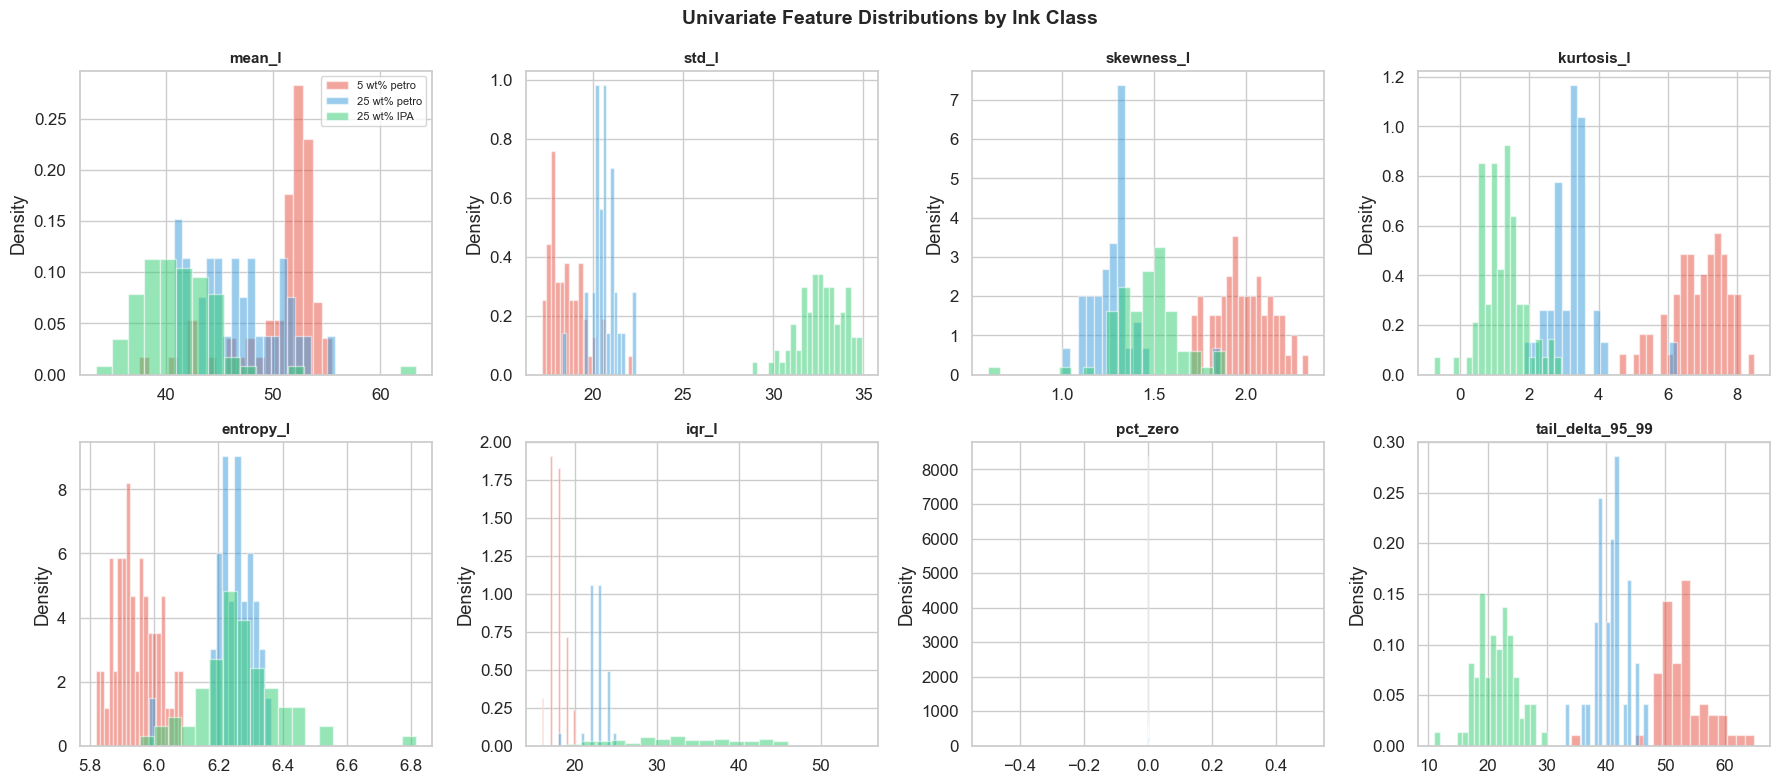

In [3]:
# Univariate feature distributions by class
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
colors = {"5 wt% petro": "#e74c3c", "25 wt% petro": "#3498db", "25 wt% IPA": "#2ecc71"}

for ax, feat in zip(axes.flat, FEATURES):
    for desc, color in colors.items():
        subset = data[data["ink_desc"] == desc][feat].dropna()
        ax.hist(subset, bins=20, alpha=0.5, color=color, label=desc, density=True)
    ax.set_title(feat, fontsize=11, fontweight="bold")
    ax.set_ylabel("Density")

axes[0, 0].legend(fontsize=8)
fig.suptitle("Univariate Feature Distributions by Ink Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. The Hard Problem: 5 wt% vs 25 wt% Petroleum

Material separation (IPA vs Petroleum) is easy — `std_I` alone does it (~32 vs ~19).
The hard problem is separating 5 wt% from 25 wt% petroleum, where features overlap significantly.

Petroleum samples: 98 ({'5 wt%': 63, '25 wt%': 35})


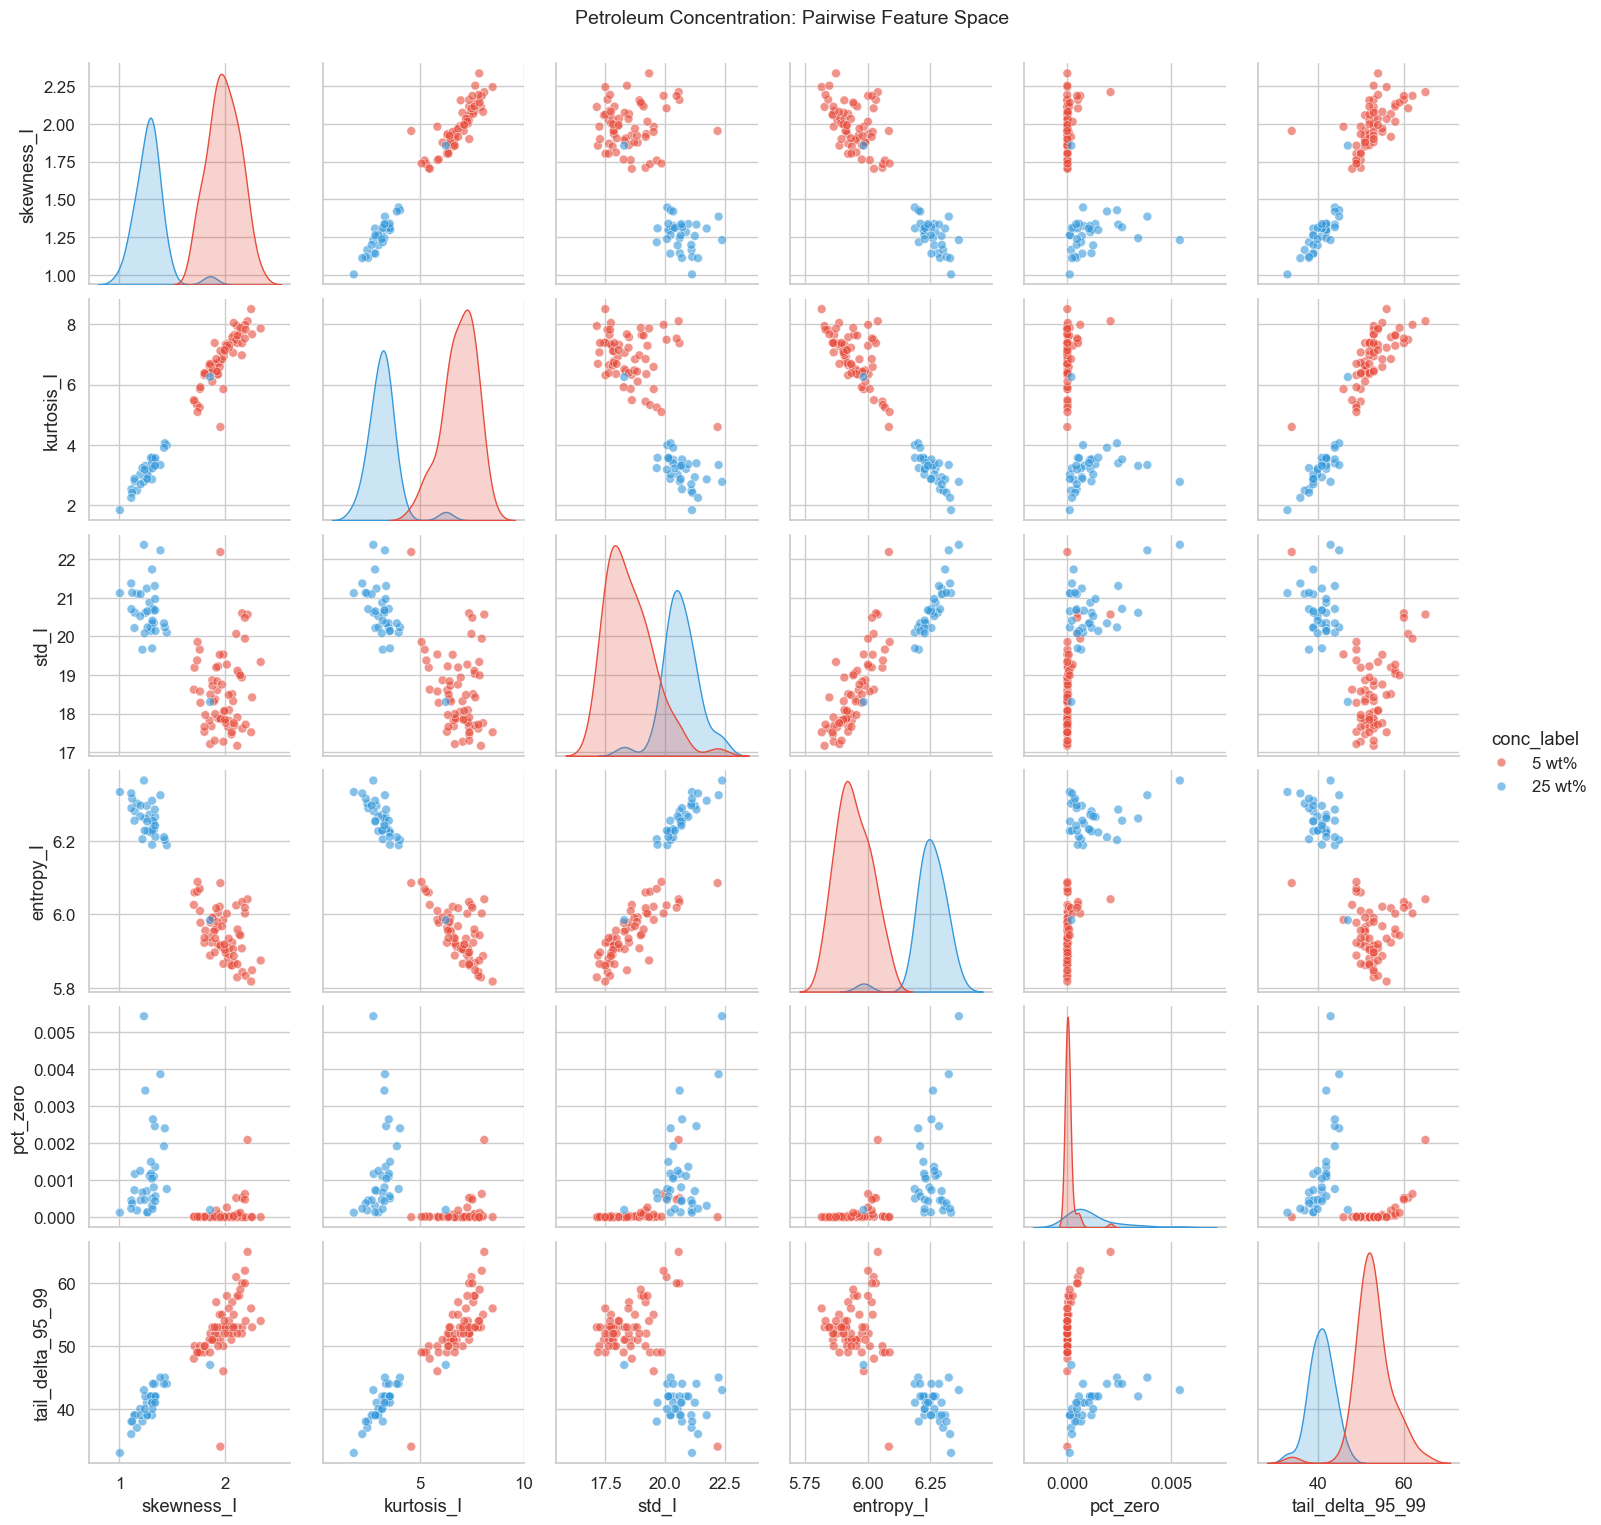

In [4]:
# petro subset already created in cell 1
print(f"Petroleum samples: {len(petro)} ({petro['conc_label'].value_counts().to_dict()})")

# Pairplot of key features for petroleum samples
key_feats = ["skewness_I", "kurtosis_I", "std_I", "entropy_I", "pct_zero", "tail_delta_95_99"]
g = sns.pairplot(
    petro, vars=key_feats, hue="conc_label",
    palette={"5 wt%": "#e74c3c", "25 wt%": "#3498db"},
    diag_kind="kde", plot_kws={"alpha": 0.6, "s": 40},
)
g.figure.suptitle("Petroleum Concentration: Pairwise Feature Space", y=1.02, fontsize=14)
plt.show()

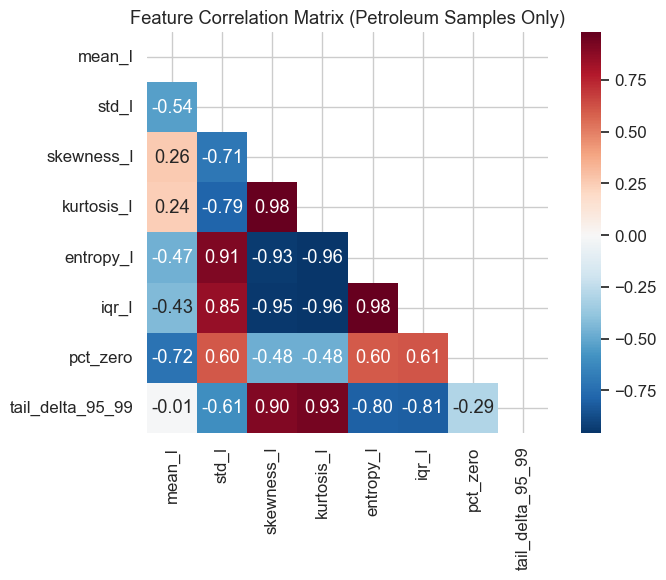

In [5]:
# Correlation matrix for petroleum features
fig, ax = plt.subplots(figsize=(8, 6))
corr = petro[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, square=True)
ax.set_title("Feature Correlation Matrix (Petroleum Samples Only)")
plt.tight_layout()
plt.show()

## 3. Class Overlap Analysis

Let's quantify exactly how much the classes overlap on each feature using:
- Cohen's d (effect size)
- Bhattacharyya distance (distribution overlap)
- ROC AUC for univariate separability

In [6]:
# roc_auc_score already imported in cell 1

g1 = petro[petro["ink_key"] == 1]  # 5 wt%
g2 = petro[petro["ink_key"] == 2]  # 25 wt%

separability = []
for feat in FEATURES:
    v1, v2 = g1[feat].dropna(), g2[feat].dropna()
    
    # Cohen's d
    pooled_std = np.sqrt(((len(v1)-1)*v1.std()**2 + (len(v2)-1)*v2.std()**2) / (len(v1)+len(v2)-2))
    d = abs(v1.mean() - v2.mean()) / pooled_std if pooled_std > 0 else 0
    
    # Univariate AUC
    y_true = np.concatenate([np.ones(len(v1)), np.zeros(len(v2))])
    scores = np.concatenate([v1.values, v2.values])
    auc = roc_auc_score(y_true, scores)
    auc = max(auc, 1 - auc)  # direction-agnostic
    
    separability.append({"feature": feat, "cohen_d": round(d, 3), "auc": round(auc, 3),
                         "5wt_mean": round(v1.mean(), 3), "25wt_mean": round(v2.mean(), 3)})

sep_df = pd.DataFrame(separability).sort_values("cohen_d", ascending=False)
print("Feature Separability (5 wt% vs 25 wt% Petroleum):\n")
print(sep_df.to_string(index=False))

Feature Separability (5 wt% vs 25 wt% Petroleum):

         feature  cohen_d   auc  5wt_mean  25wt_mean
      skewness_I    4.843 0.995     1.985      1.282
           iqr_I    4.727 0.989    17.730     22.657
      kurtosis_I    4.673 0.995     6.895      3.232
       entropy_I    4.617 0.991     5.945      6.252
tail_delta_95_99    3.084 0.984    52.857     40.829
           std_I    2.305 0.947    18.537     20.636
        pct_zero    1.422 0.957     0.000      0.001
          mean_I    1.124 0.805    50.900     46.688


## 4. Why Bayesian? Visualizing the Density Structure

kNN and LR fail because they don't model the **density** of each class.
Let's visualize the actual density structure in the most discriminative 2D projections.

Most discriminative pair: skewness_I vs iqr_I


/var/folders/g7/5jqr_hz9543_xzx_pwjg07j00000gn/T/ipykernel_49412/3797930898.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


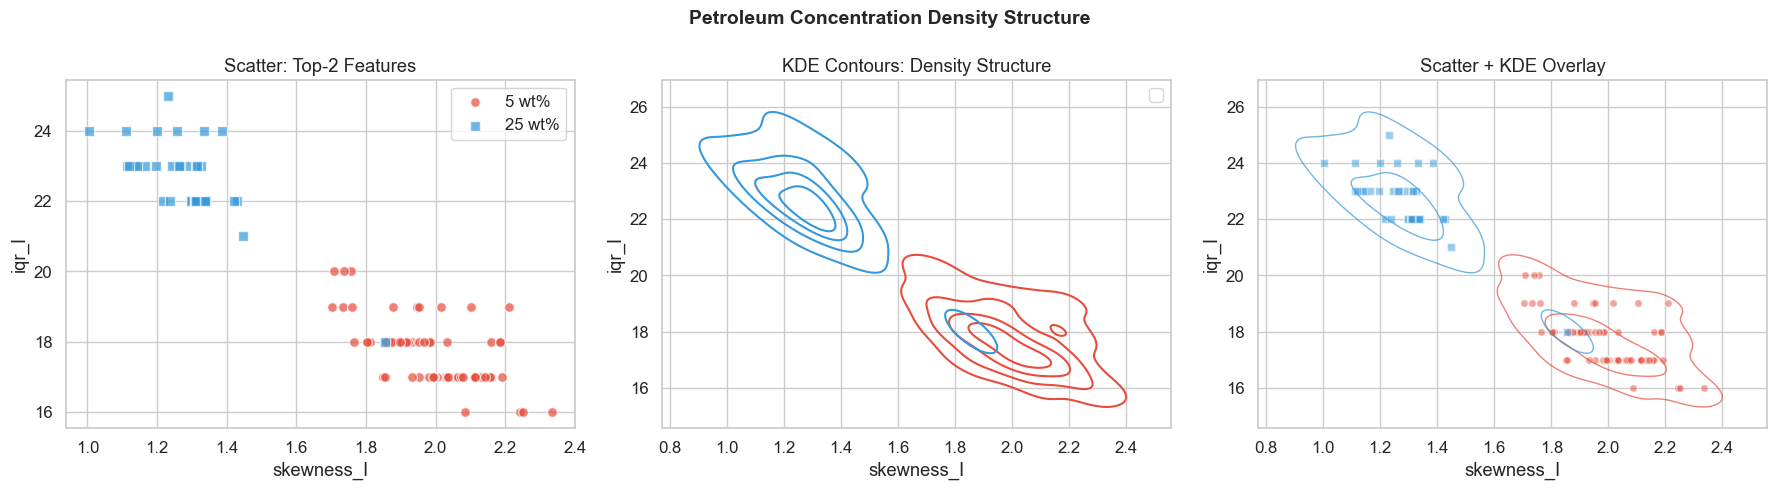

In [7]:
# Top-2 features by Cohen's d for 2D visualization
top2 = sep_df["feature"].values[:2]
print(f"Most discriminative pair: {top2[0]} vs {top2[1]}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter
for label, color, marker in [("5 wt%", "#e74c3c", "o"), ("25 wt%", "#3498db", "s")]:
    subset = petro[petro["conc_label"] == label]
    axes[0].scatter(subset[top2[0]], subset[top2[1]], c=color, marker=marker,
                    alpha=0.7, s=50, label=label, edgecolors="w")
axes[0].set_xlabel(top2[0])
axes[0].set_ylabel(top2[1])
axes[0].set_title("Scatter: Top-2 Features")
axes[0].legend()

# KDE contours for each class
for label, color in [("5 wt%", "#e74c3c"), ("25 wt%", "#3498db")]:
    subset = petro[petro["conc_label"] == label]
    sns.kdeplot(x=subset[top2[0]], y=subset[top2[1]], ax=axes[1],
                color=color, levels=5, linewidths=1.5, label=label)
axes[1].set_xlabel(top2[0])
axes[1].set_ylabel(top2[1])
axes[1].set_title("KDE Contours: Density Structure")
axes[1].legend()

# Combined: scatter + KDE
for label, color, marker in [("5 wt%", "#e74c3c", "o"), ("25 wt%", "#3498db", "s")]:
    subset = petro[petro["conc_label"] == label]
    axes[2].scatter(subset[top2[0]], subset[top2[1]], c=color, marker=marker,
                    alpha=0.5, s=30, edgecolors="w")
    sns.kdeplot(x=subset[top2[0]], y=subset[top2[1]], ax=axes[2],
                color=color, levels=3, linewidths=1, alpha=0.7)
axes[2].set_xlabel(top2[0])
axes[2].set_ylabel(top2[1])
axes[2].set_title("Scatter + KDE Overlay")

plt.suptitle("Petroleum Concentration Density Structure", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Baseline: Current Methods Performance

Before building Bayesian models, let's benchmark the existing classifiers on this data
with proper cross-validation.

In [8]:
# All imports, X_conc, y_conc, X_all, y_all, cv defined in cell 1

baselines = {
    "kNN (k=3, no scaling)": KNeighborsClassifier(n_neighbors=3),
    "kNN (k=5, scaled)": Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsClassifier(n_neighbors=5))]),
    "Logistic Reg (default)": LogisticRegression(max_iter=200),
    "Logistic Reg (scaled)": Pipeline([("scaler", StandardScaler()), ("lr", LogisticRegression(max_iter=200))]),
    "QDA (Bayesian baseline)": Pipeline([("scaler", StandardScaler()), ("qda", QuadraticDiscriminantAnalysis())]),
}

print("5-Fold CV Accuracy — Concentration Classification (5 wt% vs 25 wt%):\n")
results = {}
for name, clf in baselines.items():
    scores = cross_val_score(clf, X_conc, y_conc, cv=cv, scoring="accuracy")
    results[name] = scores
    print(f"  {name:35s}  {scores.mean():.3f} +/- {scores.std():.3f}  ({scores})")

# Also test on full 3-class material problem
print(f"\n5-Fold CV Accuracy — Material Classification (3-class):\n")
for name, clf in baselines.items():
    scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring="accuracy")
    print(f"  {name:35s}  {scores.mean():.3f} +/- {scores.std():.3f}")

5-Fold CV Accuracy — Concentration Classification (5 wt% vs 25 wt%):

  kNN (k=3, no scaling)                0.969 +/- 0.042  ([1.         1.         0.95       1.         0.89473684])
  kNN (k=5, scaled)                    0.979 +/- 0.025  ([1.         1.         0.95       1.         0.94736842])
  Logistic Reg (default)               0.979 +/- 0.025  ([1.         1.         0.95       1.         0.94736842])
  Logistic Reg (scaled)                0.979 +/- 0.025  ([1.         1.         0.95       1.         0.94736842])
  QDA (Bayesian baseline)              0.989 +/- 0.021  ([1.         1.         1.         1.         0.94736842])

5-Fold CV Accuracy — Material Classification (3-class):

  kNN (k=3, no scaling)                0.983 +/- 0.023
  kNN (k=5, scaled)                    0.994 +/- 0.011
  Logistic Reg (default)               0.989 +/- 0.014
  Logistic Reg (scaled)                0.994 +/- 0.011
  QDA (Bayesian baseline)              0.880 +/- 0.226


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The cova

## 6. Bayesian Approach 1: Gaussian Mixture Model (Generative)

A Gaussian Mixture Model per class is the simplest Bayesian density-based classifier.
Each class's feature distribution is modeled as a mixture of Gaussians, and classification
uses Bayes' rule: $P(y|x) \propto P(x|y) \cdot P(y)$.

This naturally handles:
- Dense clusters in specific regions
- Calibrated posterior probabilities
- Uncertainty (entropy of the posterior)

In [9]:
# GaussianMixture, BayesianGaussianMixture, BaseEstimator, ClassifierMixin
# all imported in cell 1


class BayesianGMMClassifier(BaseEstimator, ClassifierMixin):
    """Per-class Bayesian GMM with posterior inference."""

    def __init__(self, n_components=2, covariance_type="full", use_bayesian=True):
        self.n_components = n_components
        self.covariance_type = covariance_type
        self.use_bayesian = use_bayesian

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.models_ = {}
        self.priors_ = {}
        self.scaler_ = StandardScaler().fit(X)
        X_s = self.scaler_.transform(X)

        for c in self.classes_:
            mask = y == c
            self.priors_[c] = mask.sum() / len(y)
            GMM = BayesianGaussianMixture if self.use_bayesian else GaussianMixture
            model = GMM(
                n_components=min(self.n_components, mask.sum()),
                covariance_type=self.covariance_type,
                random_state=42,
                max_iter=500,
            )
            model.fit(X_s[mask])
            self.models_[c] = model
        return self

    def predict_proba(self, X):
        X_s = self.scaler_.transform(X)
        log_likes = np.column_stack([
            self.models_[c].score_samples(X_s) + np.log(self.priors_[c])
            for c in self.classes_
        ])
        # Numerically stable softmax
        log_likes -= log_likes.max(axis=1, keepdims=True)
        probs = np.exp(log_likes)
        probs /= probs.sum(axis=1, keepdims=True)
        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes_[probs.argmax(axis=1)]

    def predict_with_uncertainty(self, X):
        """Return predictions, probabilities, and entropy (uncertainty)."""
        probs = self.predict_proba(X)
        preds = self.classes_[probs.argmax(axis=1)]
        entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
        max_entropy = np.log(len(self.classes_))
        uncertainty = entropy / max_entropy  # normalized to [0, 1]
        return preds, probs, uncertainty


# Test on concentration task
print("Bayesian GMM Classifier — Concentration (5 wt% vs 25 wt%):\n")
for n_comp in [1, 2, 3]:
    for cov in ["full", "tied", "diag"]:
        clf = BayesianGMMClassifier(n_components=n_comp, covariance_type=cov)
        scores = cross_val_score(clf, X_conc, y_conc, cv=cv, scoring="accuracy")
        print(f"  n={n_comp}, cov={cov:5s}  →  {scores.mean():.3f} +/- {scores.std():.3f}")

Bayesian GMM Classifier — Concentration (5 wt% vs 25 wt%):

  n=1, cov=full   →  0.989 +/- 0.021
  n=1, cov=tied   →  0.989 +/- 0.021
  n=1, cov=diag   →  0.969 +/- 0.025
  n=2, cov=full   →  0.989 +/- 0.021
  n=2, cov=tied   →  0.989 +/- 0.021
  n=2, cov=diag   →  0.969 +/- 0.025
  n=3, cov=full   →  0.989 +/- 0.021
  n=3, cov=tied   →  0.989 +/- 0.021
  n=3, cov=diag   →  0.979 +/- 0.025


## 7. Bayesian Approach 2: Gaussian Process Classifier

A GP classifier provides fully Bayesian decision boundaries that are:
- Nonlinear (via the kernel)
- Uncertainty-aware (posterior variance → calibrated probabilities)
- Data-efficient (good with small training sets)

The RBF kernel naturally captures dense clusters.

In [10]:
# GaussianProcessClassifier & kernels all imported in cell 1

kernels = {
    "RBF": ConstantKernel(1.0) * RBF(length_scale=1.0),
    "Matern-1.5": ConstantKernel(1.0) * Matern(length_scale=1.0, nu=1.5),
    "Matern-2.5": ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5),
    "RatQuad": ConstantKernel(1.0) * RationalQuadratic(length_scale=1.0, alpha=1.0),
}

print("Gaussian Process Classifier — Concentration (5 wt% vs 25 wt%):\n")
gp_results = {}
for name, kernel in kernels.items():
    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("gpc", GaussianProcessClassifier(kernel=kernel, random_state=42, max_iter_predict=200)),
    ])
    scores = cross_val_score(clf, X_conc, y_conc, cv=cv, scoring="accuracy")
    gp_results[name] = scores
    print(f"  {name:15s}  →  {scores.mean():.3f} +/- {scores.std():.3f}")

# 3-class material problem
print(f"\nGaussian Process Classifier — Material (3-class):\n")
for name, kernel in kernels.items():
    clf = Pipeline([
        ("scaler", StandardScaler()),
        ("gpc", GaussianProcessClassifier(kernel=kernel, random_state=42, max_iter_predict=200)),
    ])
    scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring="accuracy")
    print(f"  {name:15s}  →  {scores.mean():.3f} +/- {scores.std():.3f}")

Gaussian Process Classifier — Concentration (5 wt% vs 25 wt%):

  RBF              →  0.979 +/- 0.025
  Matern-1.5       →  0.979 +/- 0.025
  Matern-2.5       →  0.979 +/- 0.025


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warn

  RatQuad          →  0.979 +/- 0.025

Gaussian Process Classifier — Material (3-class):

  RBF              →  0.983 +/- 0.014
  Matern-1.5       →  0.983 +/- 0.014
  Matern-2.5       →  0.983 +/- 0.014


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warn

  RatQuad          →  0.983 +/- 0.014


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__alpha is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.
  warn

## 8. Decision Boundary & Uncertainty Visualization

Let's visualize the decision boundaries and uncertainty maps for the best-performing models
on the top-2 most discriminative features.

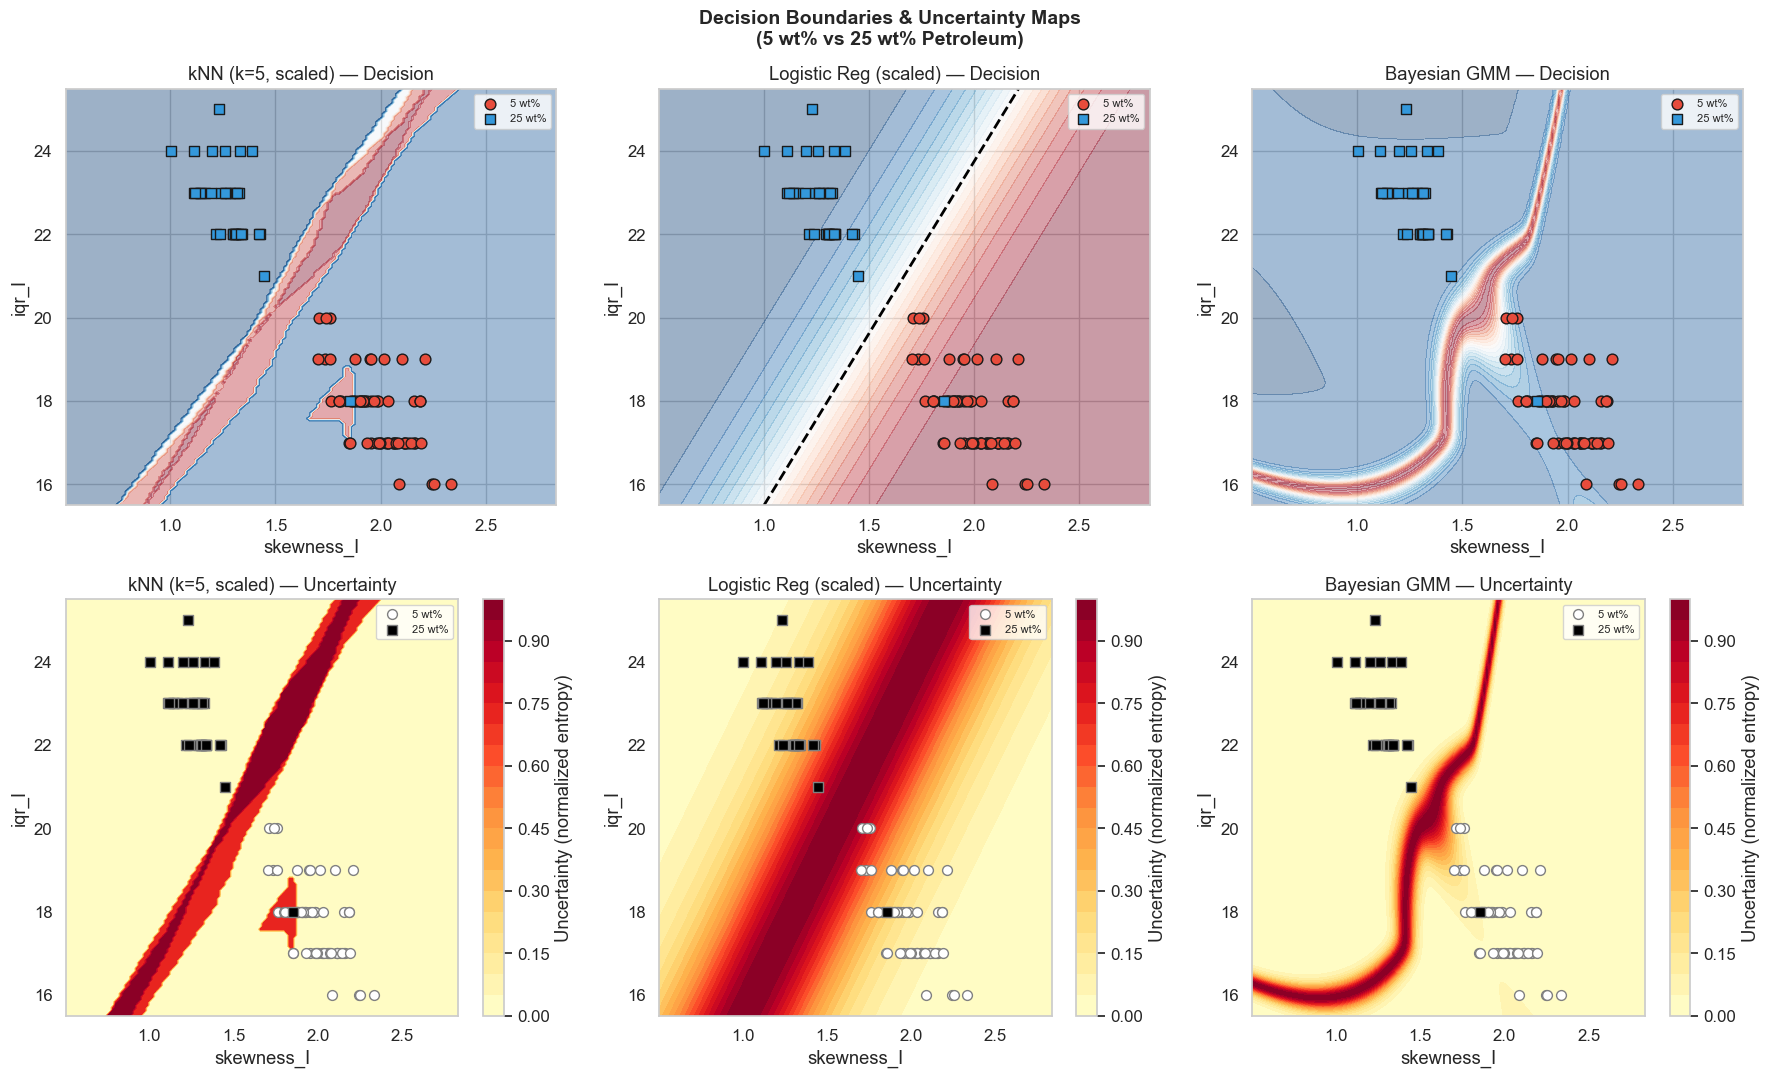

In [11]:
def plot_decision_boundary_2d(clf, X, y, feat_names, title, ax, resolution=150):
    """Plot decision boundary and uncertainty in 2D feature space."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    probs = clf.predict_proba(grid)
    # Entropy as uncertainty
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    entropy = entropy.reshape(xx.shape)

    # Decision boundary (probability contour at 0.5)
    ax.contourf(xx, yy, probs[:, 0].reshape(xx.shape), levels=20,
                cmap="RdBu", alpha=0.4)
    ax.contour(xx, yy, probs[:, 0].reshape(xx.shape), levels=[0.5],
               colors="black", linewidths=2, linestyles="--")

    # Training points
    for label, color, marker in [(1, "#e74c3c", "o"), (0, "#3498db", "s")]:
        mask = y == label
        label_text = "5 wt%" if label == 1 else "25 wt%"
        ax.scatter(X[mask, 0], X[mask, 1], c=color, marker=marker,
                   edgecolors="k", s=60, label=label_text, zorder=5)

    ax.set_xlabel(feat_names[0])
    ax.set_ylabel(feat_names[1])
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)


def plot_uncertainty_2d(clf, X, y, feat_names, title, ax, resolution=150):
    """Plot uncertainty heatmap in 2D feature space."""
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    probs = clf.predict_proba(grid)
    entropy = -np.sum(probs * np.log(probs + 1e-10), axis=1)
    max_entropy = np.log(probs.shape[1])
    uncertainty = (entropy / max_entropy).reshape(xx.shape)

    im = ax.contourf(xx, yy, uncertainty, levels=20, cmap="YlOrRd")
    plt.colorbar(im, ax=ax, label="Uncertainty (normalized entropy)")

    for label, color, marker in [(1, "white", "o"), (0, "black", "s")]:
        mask = y == label
        label_text = "5 wt%" if label == 1 else "25 wt%"
        ax.scatter(X[mask, 0], X[mask, 1], c=color, marker=marker,
                   edgecolors="gray", s=50, label=label_text, zorder=5)

    ax.set_xlabel(feat_names[0])
    ax.set_ylabel(feat_names[1])
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8)


# Use top-2 features for 2D vis
X_2d = petro[top2].fillna(0).values

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Fit models on 2D for visualization
models_2d = {
    "kNN (k=5, scaled)": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "Logistic Reg (scaled)": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=200)),
    ]),
    "Bayesian GMM": BayesianGMMClassifier(n_components=2, covariance_type="full"),
}

for i, (name, clf) in enumerate(models_2d.items()):
    clf.fit(X_2d, y_conc)
    plot_decision_boundary_2d(clf, X_2d, y_conc, list(top2), f"{name} — Decision", axes[0, i])
    plot_uncertainty_2d(clf, X_2d, y_conc, list(top2), f"{name} — Uncertainty", axes[1, i])

plt.suptitle("Decision Boundaries & Uncertainty Maps\n(5 wt% vs 25 wt% Petroleum)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Full-Feature Bayesian Models: Comprehensive Comparison

Now let's compare all methods on the full feature set with proper cross-validation,
including calibration analysis (do the predicted probabilities match true frequencies?).

In [12]:
# calibration_curve, cross_val_predict already imported in cell 1

# Full comparison on concentration task
full_models = {
    "kNN (k=5, scaled)": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "Logistic Reg (scaled)": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=200)),
    ]),
    "QDA": Pipeline([
        ("scaler", StandardScaler()),
        ("qda", QuadraticDiscriminantAnalysis()),
    ]),
    "Bayesian GMM (n=1)": BayesianGMMClassifier(n_components=1, covariance_type="full"),
    "Bayesian GMM (n=2)": BayesianGMMClassifier(n_components=2, covariance_type="full"),
    "GP (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("gpc", GaussianProcessClassifier(
            kernel=ConstantKernel(1.0) * RBF(length_scale=1.0),
            random_state=42,
        )),
    ]),
    "GP (Matern-2.5)": Pipeline([
        ("scaler", StandardScaler()),
        ("gpc", GaussianProcessClassifier(
            kernel=ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5),
            random_state=42,
        )),
    ]),
}

print("="*70)
print("COMPREHENSIVE MODEL COMPARISON")
print("Task: 5 wt% vs 25 wt% Petroleum Concentration")
print(f"Samples: {len(petro)} ({(y_conc==1).sum()} x 5wt%, {(y_conc==0).sum()} x 25wt%)")
print(f"Features: {CONC_FEATURES}")
print("="*70)

comparison = []
for name, clf in full_models.items():
    # CV accuracy
    acc_scores = cross_val_score(clf, X_conc, y_conc, cv=cv, scoring="accuracy")
    # CV probabilities for calibration
    try:
        probs_cv = cross_val_predict(clf, X_conc, y_conc, cv=cv, method="predict_proba")[:, 1]
        # Brier score (lower is better)
        brier = np.mean((probs_cv - y_conc) ** 2)
        # Log loss
        log_loss_val = -np.mean(y_conc * np.log(probs_cv + 1e-10) + (1-y_conc) * np.log(1-probs_cv + 1e-10))
    except Exception:
        brier = np.nan
        log_loss_val = np.nan
        probs_cv = None

    comparison.append({
        "model": name,
        "accuracy": f"{acc_scores.mean():.3f} +/- {acc_scores.std():.3f}",
        "brier_score": round(brier, 4) if not np.isnan(brier) else "N/A",
        "log_loss": round(log_loss_val, 4) if not np.isnan(log_loss_val) else "N/A",
    })

comp_df = pd.DataFrame(comparison)
print("\n", comp_df.to_string(index=False))

COMPREHENSIVE MODEL COMPARISON
Task: 5 wt% vs 25 wt% Petroleum Concentration
Samples: 98 (63 x 5wt%, 35 x 25wt%)
Features: ['std_I', 'skewness_I', 'kurtosis_I', 'entropy_I', 'pct_zero', 'tail_delta_95_99']


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The cova


                 model        accuracy  brier_score  log_loss
    kNN (k=5, scaled) 0.979 +/- 0.025       0.0212    0.4745
Logistic Reg (scaled) 0.979 +/- 0.025       0.0184    0.0813
                  QDA 0.989 +/- 0.021       0.0102    0.2350
   Bayesian GMM (n=1) 0.989 +/- 0.021       0.0102    0.2350
   Bayesian GMM (n=2) 0.989 +/- 0.021       0.0102    0.2350
             GP (RBF) 0.979 +/- 0.025       0.0279    0.1373
      GP (Matern-2.5) 0.979 +/- 0.025       0.0315    0.1523


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The cova

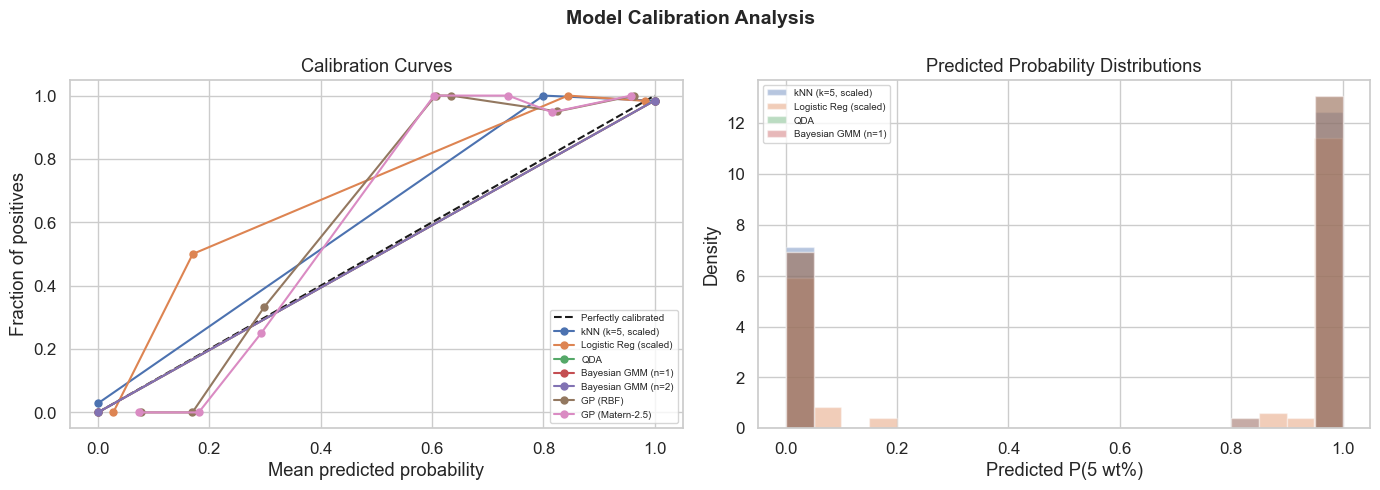

In [13]:
# Calibration curves (full_models defined in previous cell)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Calibration plot
ax = axes[0]
ax.plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")

for name, clf in full_models.items():
    try:
        probs_cv = cross_val_predict(clf, X_conc, y_conc, cv=cv, method="predict_proba")[:, 1]
        prob_true, prob_pred = calibration_curve(y_conc, probs_cv, n_bins=8)
        ax.plot(prob_pred, prob_true, "o-", label=name, markersize=5)
    except Exception:
        pass

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curves")
ax.legend(fontsize=7, loc="lower right")

# Predicted probability distributions
ax = axes[1]
for name, clf in list(full_models.items())[:4]:  # show first 4
    try:
        probs_cv = cross_val_predict(clf, X_conc, y_conc, cv=cv, method="predict_proba")[:, 1]
        ax.hist(probs_cv, bins=20, alpha=0.4, label=name, density=True)
    except Exception:
        pass

ax.set_xlabel("Predicted P(5 wt%)")
ax.set_ylabel("Density")
ax.set_title("Predicted Probability Distributions")
ax.legend(fontsize=7)

plt.suptitle("Model Calibration Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Feature Importance & Selection

Which features matter most for the Bayesian classifiers? Let's use permutation importance
and automatic relevance determination (ARD) from the GP to identify the most informative features.

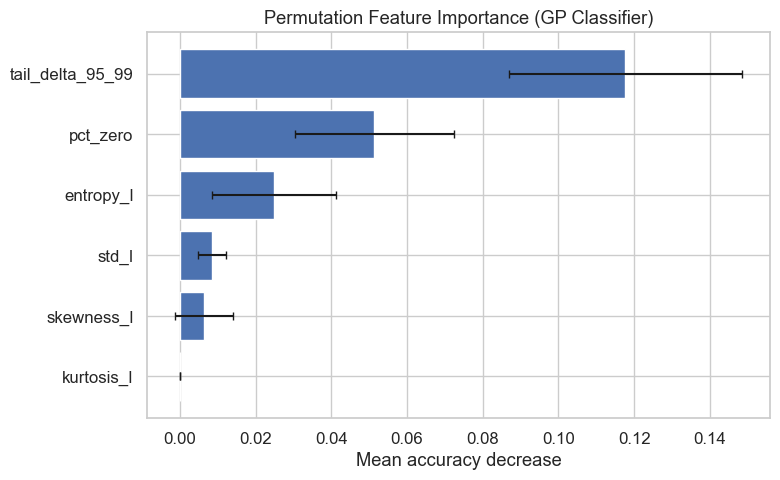


GP kernel after fitting: 16.9**2 * RBF(length_scale=5.24)
Log-marginal-likelihood: -10.975


In [14]:
# permutation_importance already imported in cell 1

# Train best model on full data
best_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("gpc", GaussianProcessClassifier(
        kernel=ConstantKernel(1.0) * RBF(length_scale=1.0),
        random_state=42,
    )),
])
best_clf.fit(X_conc, y_conc)

# Permutation importance
perm_imp = permutation_importance(best_clf, X_conc, y_conc, n_repeats=30, random_state=42)

fig, ax = plt.subplots(figsize=(8, 5))
sorted_idx = perm_imp.importances_mean.argsort()
ax.barh(
    [CONC_FEATURES[i] for i in sorted_idx],
    perm_imp.importances_mean[sorted_idx],
    xerr=perm_imp.importances_std[sorted_idx],
    capsize=3,
)
ax.set_xlabel("Mean accuracy decrease")
ax.set_title("Permutation Feature Importance (GP Classifier)")
plt.tight_layout()
plt.show()

# GP learned length scales (after fitting)
gpc = best_clf.named_steps["gpc"]
print(f"\nGP kernel after fitting: {gpc.kernel_}")
print(f"Log-marginal-likelihood: {gpc.log_marginal_likelihood_value_:.3f}")

## 11. Continuous Concentration Estimation with Uncertainty

Instead of binary classification, can we predict a **continuous** concentration value
with calibrated uncertainty bands? This is what a GP regressor naturally provides.

In [15]:
# GaussianProcessRegressor, WhiteKernel, LeaveOneOut all imported in cell 1

# Prepare regression targets
X_reg = petro[CONC_FEATURES].fillna(0).values
y_reg = petro["conc_wt"].values  # 5.0 or 25.0

# GP Regressor with uncertainty
kernel_reg = ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1.0)

gpr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("gpr", GaussianProcessRegressor(kernel=kernel_reg, random_state=42, normalize_y=True)),
])

# Leave-one-out prediction with uncertainty
loo = LeaveOneOut()
y_pred_loo = np.zeros(len(y_reg))
y_std_loo = np.zeros(len(y_reg))

for train_idx, test_idx in loo.split(X_reg):
    gpr_pipe.fit(X_reg[train_idx], y_reg[train_idx])
    gpr = gpr_pipe.named_steps["gpr"]
    X_test_s = gpr_pipe.named_steps["scaler"].transform(X_reg[test_idx])
    pred, std = gpr.predict(X_test_s, return_std=True)
    y_pred_loo[test_idx] = pred
    y_std_loo[test_idx] = std

# Results
mae = np.mean(np.abs(y_pred_loo - y_reg))
rmse = np.sqrt(np.mean((y_pred_loo - y_reg) ** 2))
print(f"LOO GP Regression: MAE = {mae:.2f} wt%, RMSE = {rmse:.2f} wt%")
print(f"Mean uncertainty (std): {y_std_loo.mean():.2f} wt%")

# Calibration: what fraction of true values fall within 1σ, 2σ?
within_1s = np.mean(np.abs(y_pred_loo - y_reg) <= y_std_loo)
within_2s = np.mean(np.abs(y_pred_loo - y_reg) <= 2 * y_std_loo)
print(f"Within 1σ: {within_1s:.1%} (expected ~68%)")
print(f"Within 2σ: {within_2s:.1%} (expected ~95%)")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better valu

LOO GP Regression: MAE = 0.68 wt%, RMSE = 2.26 wt%
Mean uncertainty (std): 1.19 wt%
Within 1σ: 82.7% (expected ~68%)
Within 2σ: 90.8% (expected ~95%)


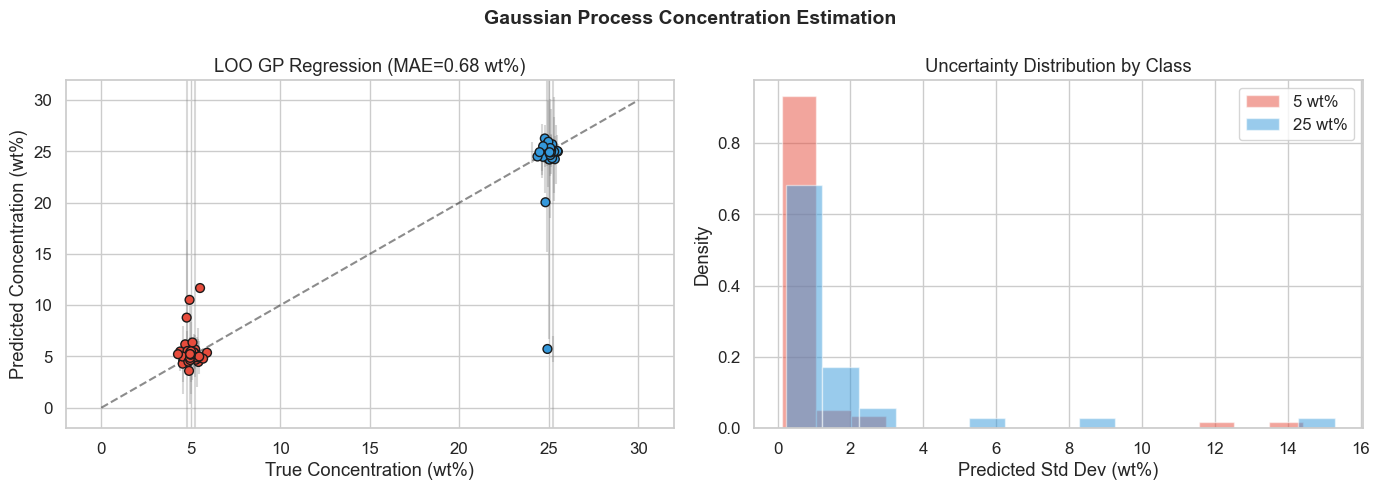

In [16]:
# Visualize LOO predictions with uncertainty
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual with error bars
ax = axes[0]
colors = ["#e74c3c" if y == 5 else "#3498db" for y in y_reg]
ax.errorbar(y_reg + np.random.normal(0, 0.3, len(y_reg)),  # jitter for visibility
            y_pred_loo, yerr=2*y_std_loo, fmt="none", ecolor="gray", alpha=0.3)
ax.scatter(y_reg + np.random.normal(0, 0.3, len(y_reg)),
           y_pred_loo, c=colors, s=40, edgecolors="k", zorder=5)
ax.plot([0, 30], [0, 30], "k--", alpha=0.5)
ax.set_xlabel("True Concentration (wt%)")
ax.set_ylabel("Predicted Concentration (wt%)")
ax.set_title(f"LOO GP Regression (MAE={mae:.2f} wt%)")
ax.set_xlim(-2, 32)
ax.set_ylim(-2, 32)

# Uncertainty distribution
ax = axes[1]
for conc, color, label in [(5.0, "#e74c3c", "5 wt%"), (25.0, "#3498db", "25 wt%")]:
    mask = y_reg == conc
    ax.hist(y_std_loo[mask], bins=15, alpha=0.5, color=color, label=label, density=True)
ax.set_xlabel("Predicted Std Dev (wt%)")
ax.set_ylabel("Density")
ax.set_title("Uncertainty Distribution by Class")
ax.legend()

plt.suptitle("Gaussian Process Concentration Estimation", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 12. 3-Class Material + Concentration: Unified Bayesian Model

Can a single model handle both material classification (IPA vs Petro) AND
concentration within petroleum? Let's test on the full 3-class problem.

In [17]:
# 3-class: ink_key in {1, 2, 3} — all variables from cell 1
print("="*70)
print("UNIFIED 3-CLASS MODEL COMPARISON")
print(f"Classes: 5wt% petro (n={(y_all==1).sum()}), 25wt% petro (n={(y_all==2).sum()}), 25wt% IPA (n={(y_all==3).sum()})")
print("="*70)

three_class_models = {
    "kNN (k=5, scaled)": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=5)),
    ]),
    "Logistic Reg (scaled)": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=200, multi_class="multinomial")),
    ]),
    "QDA": Pipeline([
        ("scaler", StandardScaler()),
        ("qda", QuadraticDiscriminantAnalysis()),
    ]),
    "Bayesian GMM (n=2)": BayesianGMMClassifier(n_components=2, covariance_type="full"),
    "GP (Matern-2.5)": Pipeline([
        ("scaler", StandardScaler()),
        ("gpc", GaussianProcessClassifier(
            kernel=ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5),
            random_state=42,
        )),
    ]),
}

for name, clf in three_class_models.items():
    scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring="accuracy")
    print(f"  {name:30s}  →  {scores.mean():.3f} +/- {scores.std():.3f}")

UNIFIED 3-CLASS MODEL COMPARISON
Classes: 5wt% petro (n=63), 25wt% petro (n=35), 25wt% IPA (n=77)
  kNN (k=5, scaled)               →  0.994 +/- 0.011
  Logistic Reg (scaled)           →  0.994 +/- 0.011
  QDA                             →  0.880 +/- 0.226
  Bayesian GMM (n=2)              →  0.994 +/- 0.011


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Pytho

  GP (Matern-2.5)                 →  0.983 +/- 0.014


Classification Report (3-class, CV predictions):

              precision    recall  f1-score   support

  5wt% petro       0.98      0.97      0.98        63
 25wt% petro       0.94      0.97      0.96        35
   25wt% IPA       1.00      1.00      1.00        77

    accuracy                           0.98       175
   macro avg       0.98      0.98      0.98       175
weighted avg       0.98      0.98      0.98       175



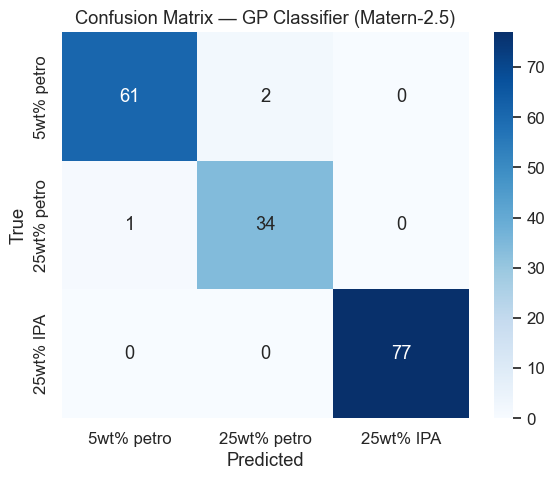

In [18]:
# confusion_matrix, classification_report already imported in cell 1

best_3class = Pipeline([
    ("scaler", StandardScaler()),
    ("gpc", GaussianProcessClassifier(
        kernel=ConstantKernel(1.0) * Matern(length_scale=1.0, nu=2.5),
        random_state=42,
    )),
])

y_pred_3c = cross_val_predict(best_3class, X_all, y_all, cv=cv)

print("Classification Report (3-class, CV predictions):\n")
target_names = ["5wt% petro", "25wt% petro", "25wt% IPA"]
print(classification_report(y_all, y_pred_3c, target_names=target_names))

# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_all, y_pred_3c)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix — GP Classifier (Matern-2.5)")
plt.tight_layout()
plt.show()

## 13. Summary & Recommendations

### Key Findings

Run the notebook to see the actual numbers and decide:

1. **Which Bayesian approach works best** for the concentration task?
2. **Which features matter** — can we reduce the feature set?
3. **How well-calibrated** are the uncertainty estimates?
4. **GP regression** — does continuous concentration estimation with uncertainty bands work?

### Next Steps

1. Port the winning model into `bjam_toolbox/ink_concentration/bayesian_classifier.py`
2. Integrate with the IC menu as a new classification option
3. Add uncertainty visualization to the output plots
4. **Reminder: Rework figure generation** — the current plotting pipeline was built for the old classifiers
   and should be redesigned for Bayesian outputs (posterior distributions, uncertainty maps, calibration plots)

In [19]:
print("\n" + "="*70)
print("REMINDER: You mentioned wanting to rework figure generation.")
print("The current plot pipeline was designed for hard classifications.")
print("Bayesian models produce posterior distributions and uncertainty —")
print("the figures should be redesigned to show:")
print("  - Posterior probability distributions per sample")
print("  - Uncertainty heatmaps over the feature space")
print("  - Calibration curves (predicted prob vs observed frequency)")
print("  - Confidence intervals on concentration estimates")
print("="*70)


REMINDER: You mentioned wanting to rework figure generation.
The current plot pipeline was designed for hard classifications.
Bayesian models produce posterior distributions and uncertainty —
the figures should be redesigned to show:
  - Posterior probability distributions per sample
  - Uncertainty heatmaps over the feature space
  - Calibration curves (predicted prob vs observed frequency)
  - Confidence intervals on concentration estimates
